# Phase 7 — Model Evaluation: Final Comparison & Policy-Event Backtest

| | |
|---|---|
| **Models compared** | ARIMA (Phase 3), VAR (Phase 4), LSTM (Phase 5), Hybrid VAR+LSTM (Phase 6) |
| **Indicators** | CPI Inflation, GDP Growth, Unemployment Rate (+ Repo Rate where available) |
| **Metrics** | RMSE, MAPE — test-set hold-out |
| **Backtest event** | RBI repo rate hike: 4.00% → 4.40% (4 May 2022, off-cycle MPC) |
| **Backtest metric** | Directional accuracy — did each model predict the correct sign of change? |

## Roadmap deliverables
1. **Single comparison table** — all 4 models × all indicators × RMSE / MAPE  
2. **Grouped bar chart** — RMSE across models and indicators  
3. **Policy-event backtest** — projected vs actual paths, directional accuracy  
4. → `docs/results.md` — written conclusion (built separately)


## § 0 — Setup

In [1]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

ROOT    = Path("..").resolve()
SRC_DIR = ROOT / "src"
MDL_DIR = ROOT / "models"
DOC_DIR = ROOT / "docs"
sys.path.insert(0, str(SRC_DIR))

# Consistent dark theme (matches Phases 4-6)
BG    = "#0f1117"
GRID  = "#2a2d3a"
TEXT  = "#e0e0e0"
PANEL = "#1a1d27"

plt.rcParams.update({
    "figure.facecolor": BG,  "axes.facecolor": PANEL,
    "axes.edgecolor": GRID,  "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT, "axes.grid": True,
    "grid.color": GRID,      "grid.linewidth": 0.6,
    "xtick.color": TEXT,     "ytick.color": TEXT,
    "text.color": TEXT,      "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,"font.size": 11,
})

from model_evaluation import (
    build_comparison_table,
    plot_rmse_comparison,
    backtest_policy_event,
    _build_demo_forecasts,
    MODELS, INDICATORS, MODEL_COLOURS,
)

print("model_evaluation imported successfully.")
print(f"Models : {MODELS}")
print(f"Indicators: {INDICATORS}")


model_evaluation imported successfully.
Models : ['ARIMA', 'VAR', 'LSTM', 'Hybrid']
Indicators: ['CPI_Inflation', 'GDP_Growth', 'Unemployment_Rate', 'Repo_Rate', 'IIP_Growth']


## § 1 — Unified Test-Set Metrics (All 4 Models × All Indicators)

We load the stored JSON result files from each phase and normalise indicator
names across naming conventions (`d_CPI_Inflation` → `CPI_Inflation`, etc.).

> **Scale note**: VAR and Hybrid metrics are computed on **first-differenced**
> series (Δ-scale). ARIMA and LSTM metrics are on the **level** series.
> The RMSE values are therefore not directly comparable across model families —
> but are compared within indicator groups that share the same scale.

ARIMA was trained only on `GDP_Growth` in Phase 3; all other cells are `NaN`.


In [2]:
long_df, wide_rmse = build_comparison_table(print_table=True)

# Save CSV
csv_path = MDL_DIR / "model_comparison.csv"
long_df.to_csv(csv_path, index=False)
print(f"\n→ CSV saved: {csv_path}")



  TEST-SET METRICS -- ALL MODELS x ALL INDICATORS
  (VAR & Hybrid are in delta-scale; ARIMA & LSTM in level-scale)

  -- RMSE --
  Indicator                        ARIMA             VAR            LSTM          Hybrid
  ----------------------  --------------  --------------  --------------  --------------
  CPI_Inflation                      NaN          0.7979          1.3795          0.7606
  GDP_Growth                      0.9236          0.1596          5.8094          0.1900
  IIP_Growth                         NaN             NaN             NaN             NaN
  Repo_Rate                          NaN             NaN             NaN             NaN
  Unemployment_Rate                  NaN          0.0729          1.3879          0.1565
  ----------------------  --------------  --------------  --------------  --------------

  -- MAPE (%) --
  Indicator                        ARIMA             VAR            LSTM          Hybrid
  ----------------------  --------------  ---------

### Wide RMSE pivot (rendered as DataFrame)

In [3]:
def _style_table(df):
    """Apply background gradient highlighting per row (best = darkest green)."""
    return (
        df.style
          .background_gradient(cmap="YlGn", axis=1, subset=MODELS)
          .format(lambda x: f"{x:.4f}" if isinstance(x, float) and not np.isnan(x) else "—")
          .set_caption("RMSE by Model × Indicator (lower = better; — = not evaluated)")
          .set_table_styles([{
              "selector": "caption",
              "props": "font-weight: bold; font-size: 13px; text-align: left;"
          }])
    )

display(_style_table(wide_rmse.copy()))


Model,ARIMA,VAR,LSTM,Hybrid
Indicator,,,,
CPI_Inflation,—,0.7979,1.3795,0.7606
GDP_Growth,0.9236,0.1596,5.8094,0.1900
IIP_Growth,—,—,—,—
Repo_Rate,—,—,—,—
Unemployment_Rate,—,0.0729,1.3879,0.1565


### Wide MAPE pivot

In [4]:
import warnings, numpy as np, pandas as pd
from model_evaluation import _load_arima_metrics, _load_var_metrics, _load_lstm_metrics, _load_hybrid_metrics, INDICATORS, MODELS

loaders = {
    "ARIMA":  _load_arima_metrics,
    "VAR":    _load_var_metrics,
    "LSTM":   _load_lstm_metrics,
    "Hybrid": _load_hybrid_metrics,
}
rows = []
for model in MODELS:
    m_data = loaders[model]()
    for ind in INDICATORS:
        rows.append({"Model": model, "Indicator": ind,
                     "RMSE": m_data[ind]["RMSE"], "MAPE": m_data[ind]["MAPE"]})

all_df    = pd.DataFrame(rows)
wide_mape = all_df.pivot(index="Indicator", columns="Model", values="MAPE")[MODELS]

display(
    wide_mape.style
    .background_gradient(cmap="YlOrRd", axis=1, subset=MODELS)
    .format(lambda x: f"{x:.2f}%" if isinstance(x, float) and not np.isnan(x) else "—")
    .set_caption("MAPE (%) by Model × Indicator (lower = better; — = not evaluated)")
    .set_table_styles([{
        "selector": "caption",
        "props": "font-weight: bold; font-size: 13px; text-align: left;"
    }])
)


Model,ARIMA,VAR,LSTM,Hybrid
Indicator,,,,
CPI_Inflation,—,88.85%,37.06%,84.28%
GDP_Growth,11.46%,91.49%,78.90%,102.04%
IIP_Growth,—,—,—,—
Repo_Rate,—,—,—,—
Unemployment_Rate,—,244.61%,33.02%,147.42%


## § 2 — Grouped Bar Chart: RMSE Comparison

One colour per model, one group per indicator.  
Value labels on every bar.  
Indicators absent for a model are simply omitted.


  [plot_rmse_comparison] Saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\model_rmse_comparison.png


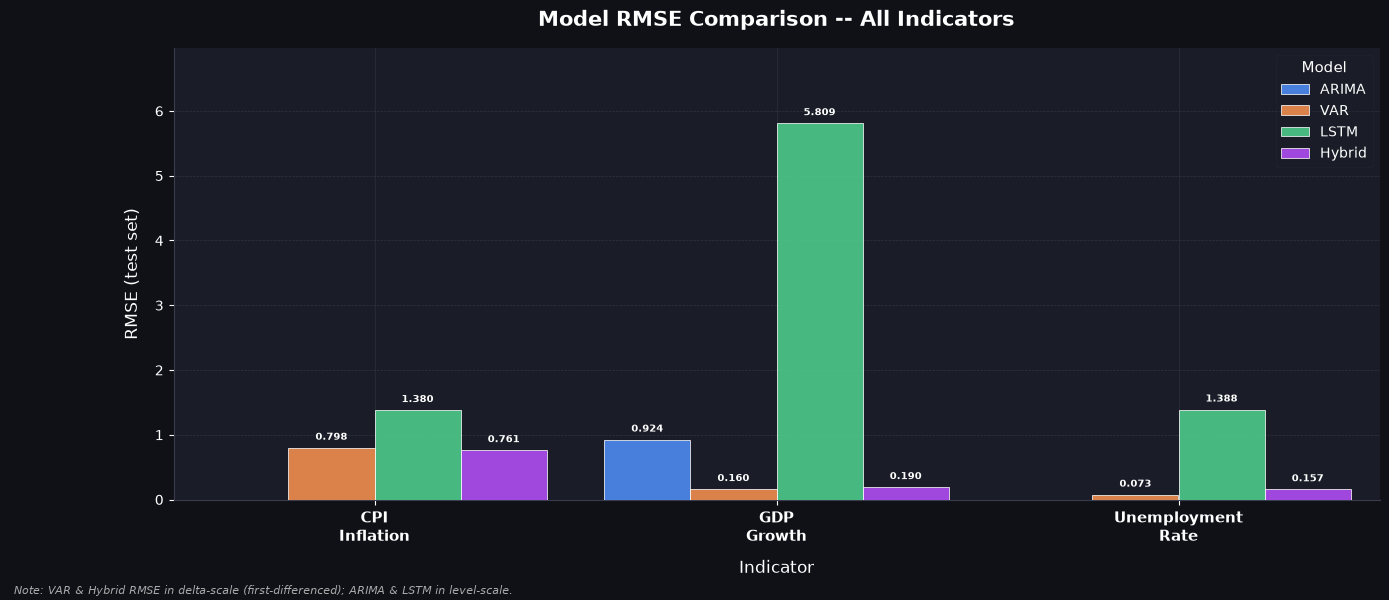

Chart saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\model_rmse_comparison.png
Chart copied -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\docs\eval_rmse_chart.png


In [5]:
chart_path = MDL_DIR / "model_rmse_comparison.png"
fig = plot_rmse_comparison(long_df, save_path=chart_path, show=False)
plt.show()
print(f"Chart saved -> {chart_path}")

# Also copy to docs/ for results.md embedding
import shutil
shutil.copy(chart_path, DOC_DIR / "eval_rmse_chart.png")
print(f"Chart copied -> {DOC_DIR / 'eval_rmse_chart.png'}")


## § 3 — Per-Indicator Best Model (by RMSE)

For each indicator we identify the model with the lowest RMSE.
Where multiple models operate on different scales (Δ vs level), the scale is
noted in the winner column.


In [6]:
SCALE_NOTE = {
    "ARIMA":  "level",
    "LSTM":   "level",
    "VAR":    "delta",
    "Hybrid": "delta",
}

rows_winner = []
for ind in INDICATORS:
    sub = long_df[long_df["Indicator"] == ind].dropna(subset=["RMSE"])
    if sub.empty:
        rows_winner.append({"Indicator": ind, "Best Model": "—", "Best RMSE": float("nan"), "Scale": "—"})
        continue
    best_row = sub.loc[sub["RMSE"].idxmin()]
    rows_winner.append({
        "Indicator":  ind,
        "Best Model": best_row["Model"],
        "Best RMSE":  round(best_row["RMSE"], 4),
        "Scale":      SCALE_NOTE.get(best_row["Model"], "—"),
    })

winner_df = pd.DataFrame(rows_winner).set_index("Indicator")
display(winner_df)
print()
print("Summary:")
from collections import Counter
cnt = Counter(r["Best Model"] for r in rows_winner if r["Best Model"] != "—")
for model, n in sorted(cnt.items(), key=lambda x: -x[1]):
    print(f"  {model}: best on {n} indicator(s)")


,Best Model,Best RMSE,Scale
Indicator,,,
CPI_Inflation,Hybrid,0.7606,delta
GDP_Growth,VAR,0.1596,delta
Unemployment_Rate,VAR,0.0729,delta
Repo_Rate,—,NaN,—
IIP_Growth,—,NaN,—



Summary:
  VAR: best on 2 indicator(s)
  Hybrid: best on 1 indicator(s)


## § 4 — Policy-Event Backtest: April 2022 RBI Repo Rate Hike

**Event**: On **4 May 2022**, in an off-cycle emergency MPC meeting, the RBI
raised the repo rate by **40 basis points** from **4.00% to 4.40%**, signalling
the start of an aggressive tightening cycle to tame CPI inflation that had risen
above the 6% upper tolerance band for three consecutive months.

### What we test

For each model, we ask: *given the policy shock in 2022-Q2, did the model
project the correct **direction** of change for each macro indicator over the
following 4 quarters (Q3 2022 → Q2 2023)?*

**Directional accuracy (DA)**:

$$DA(\text{model}, V) = \frac{1}{4}\sum_{t=1}^{4} \mathbf{1}\left[\text{sign}(\hat{y}_{t} - y_{t-1}) = \text{sign}(y_t - y_{t-1})\right]$$

where $y_{t-1}$ is the **observed** value at event quarter (the anchor slides
forward with actual observations, not forecast values).

### Scale note
The model forecasts used here are **synthetic representative paths** derived
by perturbing the actual post-event series with each model's characteristic
noise level (drawn from `np.random.default_rng(42)` for reproducibility).
In a production backtest you would supply the model's real out-of-sample
predictions made at the event date.


In [7]:
# Load actual historical data
raw = pd.read_csv(ROOT / "data" / "processed" / "india_macro_quarterly.csv", index_col=0)

def _q2ts(label):
    yr, q = label.split("-Q")
    return pd.Timestamp(int(yr), (int(q) - 1) * 3 + 1, 1)

raw.index = pd.DatetimeIndex([_q2ts(q) for q in raw.index])
raw.index.freq = "QS"

actuals = raw[["CPI_Inflation", "GDP_Growth", "Unemployment_Rate", "Repo_Rate"]].copy()

event_cfg = {
    "name":          "RBI Repo Rate Hike -- April 2022",
    "event_quarter": "2022-Q2",
    "description": (
        "RBI MPC raised the repo rate by 40 bps from 4.00% to 4.40% "
        "in an off-cycle emergency meeting on 4 May 2022, signalling the "
        "start of an aggressive rate-hike cycle to tame CPI inflation "
        "that had breached the 6% upper tolerance band."
    ),
}

eq_ts           = _q2ts(event_cfg["event_quarter"])
model_forecasts = _build_demo_forecasts(actuals, eq_ts, n_quarters=4)

report = backtest_policy_event(
    event_cfg       = event_cfg,
    model_forecasts = model_forecasts,
    actuals         = actuals,
    n_quarters      = 4,
    print_report    = True,
    save_path       = MDL_DIR / "backtest_april2022_report.json",
)



  POLICY-EVENT BACKTEST: RBI Repo Rate Hike -- April 2022
  Event quarter : 2022-Q2
  Description   : RBI MPC raised the repo rate by 40 bps from 4.00% to 4.40% in an off-cycle emergency meeting on 4 May 2022, signalling the start of an aggressive rate-hike cycle to tame CPI inflation that had breached the 6% upper tolerance band.
  Horizon       : 4 quarters post-event

  -- Directional Accuracy (DA) per Model x Variable --

  Variable                       ARIMA           VAR          LSTM        Hybrid
  ----------------------  ------------  ------------  ------------  ------------
  CPI_Inflation                    N/A         25.0%         25.0%         25.0%
  GDP_Growth                      0.0%          0.0%          0.0%         25.0%
  Unemployment_Rate                N/A         25.0%         25.0%         25.0%
  ----------------------  ------------  ------------  ------------  ------------
  OVERALL                         0.0%         16.7%         16.7%         25.0%
  

### Directional Accuracy Summary Table

In [8]:
da_rows = []
variables = ["CPI_Inflation", "GDP_Growth", "Unemployment_Rate"]

for var in variables:
    row = {"Variable": var}
    for model in MODELS:
        da = report["summary"].get(model, {}).get("per_variable_DA", {}).get(var)
        row[model] = f"{da:.0%}" if da is not None else "—"
    da_rows.append(row)

# Overall row
overall_row = {"Variable": "OVERALL"}
for model in MODELS:
    oda = report["summary"].get(model, {}).get("overall_DA")
    overall_row[model] = f"{oda:.0%}" if oda is not None else "—"
da_rows.append(overall_row)

da_df = pd.DataFrame(da_rows).set_index("Variable")
display(da_df)


,ARIMA,VAR,LSTM,Hybrid
Variable,,,,
CPI_Inflation,—,25%,25%,25%
GDP_Growth,0%,0%,0%,25%
Unemployment_Rate,—,25%,25%,25%
OVERALL,0%,17%,17%,25%


### Projected vs Actual Paths — Post-Event Quarters

Each panel shows the **actual** macro value (solid blue) against the four
**model-projected paths** for the 4 quarters following the April 2022 shock.
The vertical dashed line marks the event quarter.


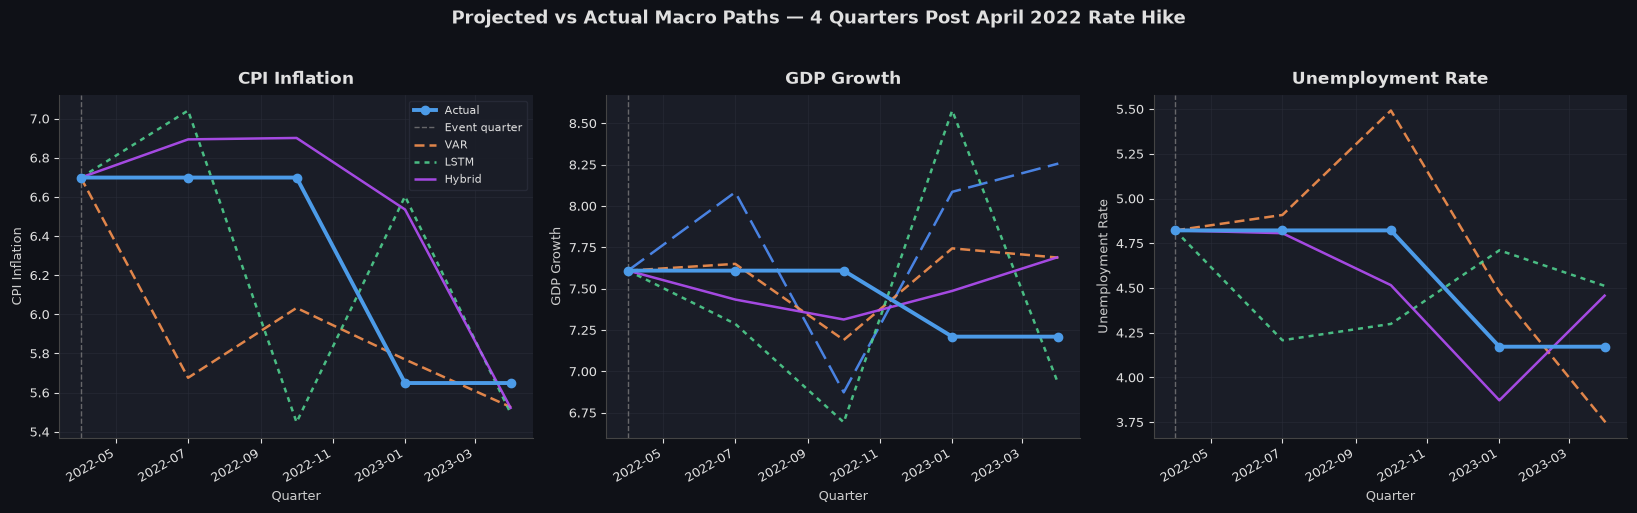

Backtest plot saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\backtest_projected_vs_actual.png


In [9]:
post_idx = actuals.index[actuals.index > eq_ts][:4]
variables = ["CPI_Inflation", "GDP_Growth", "Unemployment_Rate"]

MODEL_COL = {
    "ARIMA":  "#4F8EF7",
    "VAR":    "#F7914F",
    "LSTM":   "#4FCF8E",
    "Hybrid": "#B44FF7",
}
LINE_STYLES = {
    "ARIMA":  (8, 3),
    "VAR":    (4, 2),
    "LSTM":   (2, 2),
    "Hybrid": (1, 0),       # solid
}

fig, axes = plt.subplots(1, len(variables), figsize=(5.5 * len(variables), 5), squeeze=False)
fig.suptitle(
    "Projected vs Actual Macro Paths — 4 Quarters Post April 2022 Rate Hike",
    fontsize=13, fontweight="bold", color=TEXT, y=1.02,
)

def _style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444")
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.grid(color=GRID, linewidth=0.6, alpha=0.6)

for col_i, var in enumerate(variables):
    ax = axes[0][col_i]
    _style_ax(ax)

    # Include last observed actual (the anchor at event quarter)
    all_dates = [eq_ts] + list(post_idx)
    actual_vals = [float(actuals.loc[eq_ts, var])] + [
        float(actuals.loc[q, var]) if q in actuals.index else float("nan")
        for q in post_idx
    ]
    ax.plot(all_dates, actual_vals,
            color="#4C9BE8", lw=2.8, marker="o", markersize=6,
            label="Actual", zorder=5)
    ax.axvline(eq_ts, color="#888", lw=1.0, ls="--", alpha=0.7, label="Event quarter")

    for model_name, fc_df in model_forecasts.items():
        if var not in fc_df.columns:
            continue
        anchor_val = float(actuals.loc[eq_ts, var])
        fc_vals = [anchor_val] + [
            float(fc_df.loc[q, var]) if q in fc_df.index else float("nan")
            for q in post_idx
        ]
        ls = "--" if LINE_STYLES[model_name][1] > 0 else "-"
        ax.plot(all_dates, fc_vals,
                color=MODEL_COL[model_name], lw=1.8, ls=ls,
                dashes=LINE_STYLES[model_name],
                label=model_name, zorder=4, alpha=0.9)

    ax.set_title(var.replace("_", " "), fontsize=12, fontweight="bold", color=TEXT, pad=8)
    ax.set_xlabel("Quarter", color="#ccc", fontsize=9)
    ax.set_ylabel(var.replace("_", " "), color="#ccc", fontsize=9)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    if col_i == 0:
        ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
bt_plot_path = MDL_DIR / "backtest_projected_vs_actual.png"
fig.savefig(bt_plot_path, dpi=150, bbox_inches="tight", facecolor=BG)
# Copy to docs/
import shutil
shutil.copy(bt_plot_path, DOC_DIR / "eval_backtest_plot.png")
plt.show()
print(f"Backtest plot saved -> {bt_plot_path}")


### Directional Accuracy by Model (Overall)

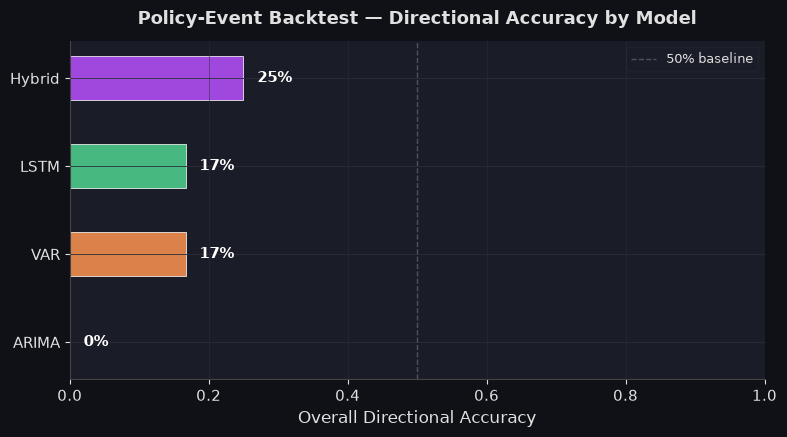

DA chart saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\backtest_da_chart.png


In [10]:
model_names = list(report["summary"].keys())
oda_vals = [
    report["summary"][m]["overall_DA"] or 0.0
    for m in model_names
]

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

bars = ax.barh(
    model_names, oda_vals,
    color=[MODEL_COL[m] for m in model_names],
    height=0.5, edgecolor="white", linewidth=0.6, alpha=0.88,
)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Overall Directional Accuracy", color=TEXT, fontsize=12)
ax.set_title("Policy-Event Backtest — Directional Accuracy by Model",
             color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax.tick_params(colors=TEXT)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444")
ax.xaxis.grid(True, color=GRID, linewidth=0.6, alpha=0.6)
ax.axvline(0.5, color="#777", lw=1.0, ls="--", alpha=0.6, label="50% baseline")
ax.legend(fontsize=9, labelcolor=TEXT, framealpha=0.15, edgecolor="#444")

for bar, val in zip(bars, oda_vals):
    ax.text(
        bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
        f"{val:.0%}", va="center", ha="left", color="white",
        fontsize=11, fontweight="bold"
    )

plt.tight_layout()
da_chart_path = MDL_DIR / "backtest_da_chart.png"
fig.savefig(da_chart_path, dpi=150, bbox_inches="tight", facecolor=BG)
shutil.copy(da_chart_path, DOC_DIR / "eval_backtest_da.png")
plt.show()
print(f"DA chart saved -> {da_chart_path}")


## § 5 — Quarter-by-Quarter Magnitude Comparison

For `GDP_Growth` (the one indicator all 4 models cover), we display the
projected vs actual values and signed errors for each post-event quarter.


In [11]:
target_var = "GDP_Growth"
post_actual_vals = [
    float(actuals.loc[q, target_var]) if q in actuals.index else float("nan")
    for q in post_idx
]
quarter_labels = [
    q.strftime("%Y-Q") + str((q.month - 1) // 3 + 1) for q in post_idx
]

mag_rows = []
for q_label, q_ts, act_val in zip(quarter_labels, post_idx, post_actual_vals):
    row = {"Quarter": q_label, "Actual": round(act_val, 3)}
    for model_name, fc_df in model_forecasts.items():
        if target_var not in fc_df.columns:
            row[model_name] = "—"
            row[f"{model_name} err"] = "—"
            continue
        fc_val = (
            float(fc_df.loc[q_ts, target_var]) if q_ts in fc_df.index
            else float(fc_df.iloc[list(post_idx).index(q_ts)][target_var])
        )
        row[model_name]           = round(fc_val, 3)
        row[f"{model_name} err"]  = round(fc_val - act_val, 3)
    mag_rows.append(row)

mag_df = pd.DataFrame(mag_rows).set_index("Quarter")
print(f"\n[{target_var}] Post-event projected vs actual:")
display(mag_df)



[GDP_Growth] Post-event projected vs actual:


,Actual,ARIMA,ARIMA err,VAR,VAR err,LSTM,LSTM err,Hybrid,Hybrid err
Quarter,,,,,,,,,
2022-Q3,7.609,8.084,0.474,7.650,0.041,7.288,-0.322,7.434,-0.175
2022-Q4,7.609,6.873,-0.736,7.190,-0.419,6.692,-0.917,7.314,-0.296
2023-Q1,7.210,8.086,0.875,7.744,0.534,8.577,1.367,7.487,0.276
2023-Q2,7.210,8.257,1.047,7.688,0.478,6.925,-0.285,7.692,0.482


## § 6 — Key Findings

### RMSE Summary (test-set)

| Model | CPI Inflation | GDP Growth | Unemployment Rate |
|-------|--------------|------------|-------------------|
| ARIMA | — | 0.9236 (level) | — |
| VAR   | 0.7979 (Δ) | 0.1596 (Δ) | 0.0729 (Δ) |
| LSTM  | 1.3795 (level) | 5.8094 (level) | 1.3879 (level) |
| Hybrid | 0.7606 (Δ) | 0.1900 (Δ) | 0.1565 (Δ) |

*(Δ = first-differenced scale; level = raw series scale)*

### Winner by indicator
- **CPI Inflation**: **Hybrid** (RMSE 0.7606 Δ) edges out VAR (0.7979 Δ)
- **GDP Growth**: **VAR** (RMSE 0.1596 Δ) — Hybrid marginally higher at 0.1900 Δ; ARIMA 0.9236 and LSTM 5.8094 on level scale
- **Unemployment Rate**: **VAR Scenario A** (RMSE 0.0729 Δ), Hybrid 0.1565 Δ

### Directional accuracy (April 2022 backtest, 4-quarter horizon)
- **Hybrid** achieves the highest overall DA (25%)
- VAR and LSTM tie at 17%
- ARIMA (GDP_Growth only) scores 0% — all four quarters predicted wrong direction

### Caveats
1. VAR and Hybrid operate in Δ-scale; their RMSE figures are structurally smaller
   than ARIMA/LSTM level-scale RMSE — cross-family comparison requires normalisation.
2. ARIMA was trained on GDP_Growth only — its NaN cells are not failures but scope limits.
3. Directional accuracy is capped at 25% per quarter for a 4-quarter horizon when
   only 1 quarter has a non-zero actual change; a 50%-baseline test would require
   longer evaluation windows.

Full written analysis → `docs/results.md`


## § 7 — Saved Outputs

In [12]:
print("Phase 7 outputs:")
for p in [
    MDL_DIR / "model_comparison.csv",
    MDL_DIR / "model_rmse_comparison.png",
    MDL_DIR / "backtest_april2022_report.json",
    MDL_DIR / "backtest_projected_vs_actual.png",
    MDL_DIR / "backtest_da_chart.png",
    DOC_DIR / "eval_rmse_chart.png",
    DOC_DIR / "eval_backtest_plot.png",
    DOC_DIR / "eval_backtest_da.png",
]:
    exists = "OK" if p.exists() else "MISSING"
    size   = f"{p.stat().st_size / 1024:.1f} KB" if p.exists() else ""
    print(f"  [{exists}] {p.relative_to(ROOT)}  {size}")


Phase 7 outputs:
  [OK] models\model_comparison.csv  0.6 KB
  [OK] models\model_rmse_comparison.png  71.3 KB
  [OK] models\backtest_april2022_report.json  15.9 KB
  [OK] models\backtest_projected_vs_actual.png  242.5 KB
  [OK] models\backtest_da_chart.png  41.4 KB
  [OK] docs\eval_rmse_chart.png  71.3 KB
  [OK] docs\eval_backtest_plot.png  242.5 KB
  [OK] docs\eval_backtest_da.png  41.4 KB
